<a href="https://colab.research.google.com/github/aha2003/brain-tumor-classfication-FYP2025/blob/main/Deit_VIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300
})


MAIN_COLOR = '#2471A3'

In [2]:
!pip install timm

In [3]:
import tensorflow as tf
import os
from google.colab import drive

drive.mount('/content/drive')

base_path = '/content/drive/My Drive/Kaggle_Datasets/mri-brain-tumor-dataset'
train_dir = os.path.join(base_path, 'Training')
test_dir = os.path.join(base_path, 'Testing')

IMG_SIZE = (224, 224)
BATCH_SIZE = 16


val_split_pct = 450 / 2935

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=val_split_pct, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=val_split_pct, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

Mounted at /content/drive
Found 2870 files belonging to 4 classes.
Using 2430 files for training.
Found 2870 files belonging to 4 classes.
Using 440 files for validation.
Found 394 files belonging to 4 classes.


In [4]:
import tensorflow as tf


def prepare_vit_ds(ds):

    normalization_layer = tf.keras.layers.Rescaling(1./127.5, offset=-1)
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds_vit = prepare_vit_ds(train_ds)
val_ds_vit = prepare_vit_ds(val_ds)
test_ds_vit = prepare_vit_ds(test_ds)

In [5]:
import torch
import torch.nn as nn
import timm
from tqdm import tqdm


model_deit = timm.create_model('deit_base_distilled_patch16_224', pretrained=True)


for param in model_deit.parameters():
    param.requires_grad = False


num_features = model_deit.head.in_features
model_deit.head = nn.Linear(num_features, 4)
model_deit.head_dist = nn.Linear(num_features, 4)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_deit.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model_deit.parameters()), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/349M [00:00<?, ?B/s]

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm

def train_phase1(model, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0


        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):

            images = torch.from_numpy(images.numpy()).permute(0, 3, 1, 2).to(device).float() / 255.0
            labels = torch.from_numpy(labels.numpy()).to(device).argmax(dim=1)

            optimizer.zero_grad()


            raw_output = model(images)


            if isinstance(raw_output, (tuple, list)):
                outputs, outputs_dist = raw_output
                loss = (criterion(outputs, labels) + criterion(outputs_dist, labels)) / 2
            else:
                outputs = raw_output
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        print(f"Epoch {epoch+1} - Avg Loss: {running_loss/len(train_loader):.4f} | Training Acc: {train_acc:.2f}%")

# Execute Phase 1
print("Starting DeiT Phase 1: Feature Extraction (PyTorch/timm)...")
train_phase1(model_deit, train_ds, val_ds)

Starting DeiT Phase 1: Feature Extraction (PyTorch/timm)...


Epoch 1/10: 100%|██████████| 152/152 [26:32<00:00, 10.48s/it]


Epoch 1 - Avg Loss: 1.1378 | Training Acc: 57.74%


Epoch 2/10: 100%|██████████| 152/152 [26:29<00:00, 10.45s/it]


Epoch 2 - Avg Loss: 0.8235 | Training Acc: 77.49%


...

Epoch 8 - Avg Loss: 0.4301 | Training Acc: 86.34%


Epoch 9/10: 100%|██████████| 152/152 [25:58<00:00, 10.26s/it]


Epoch 9 - Avg Loss: 0.4084 | Training Acc: 87.00%


Epoch 10/10: 100%|██████████| 152/152 [26:21<00:00, 10.41s/it]

Epoch 10 - Avg Loss: 0.3903 | Training Acc: 87.98%


In [ ]:

for param in model_deit.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model_deit.parameters(), lr=1e-5)

print("Backbone unfrozen. Model ready for Phase 2 Fine-Tuning.")

Backbone unfrozen. Model ready for Phase 2 Fine-Tuning.


In [ ]:
def train_phase2(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        # training phase
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Fine-Tuning Epoch {epoch+1}/{epochs}"):
            images = torch.from_numpy(images.numpy()).permute(0, 3, 1, 2).to(device).float() / 255.0
            labels = torch.from_numpy(labels.numpy()).to(device).argmax(dim=1)

            optimizer.zero_grad()
            raw_output = model(images)

            if isinstance(raw_output, (tuple, list)):
                outputs, outputs_dist = raw_output
                loss = (criterion(outputs, labels) + criterion(outputs_dist, labels)) / 2
            else:
                outputs = raw_output
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        # validation phase
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = torch.from_numpy(images.numpy()).permute(0, 3, 1, 2).to(device).float() / 255.0
                labels = torch.from_numpy(labels.numpy()).to(device).argmax(dim=1)


                outputs = model(images)
                if isinstance(outputs, (tuple, list)):
                    outputs = outputs[0]

                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        print(f"Epoch {epoch+1} | Train Acc: {100.*train_correct/train_total:.2f}% | Val Acc: {100.*val_correct/val_total:.2f}%")


train_phase2(model_deit, train_ds, val_ds, epochs=5)

torch.save(model_deit.state_dict(), os.path.join(base_path, 'deit_final_finetuned.pth'))

Fine-Tuning Epoch 1/5: 100%|██████████| 152/152 [1:15:21<00:00, 29.74s/it]


Epoch 1 | Train Acc: 90.95% | Val Acc: 94.09%


Fine-Tuning Epoch 2/5: 100%|██████████| 152/152 [1:15:37<00:00, 29.86s/it]


Epoch 2 | Train Acc: 98.19% | Val Acc: 94.32%


Fine-Tuning Epoch 3/5: 100%|██████████| 152/152 [1:14:57<00:00, 29.59s/it]


Epoch 3 | Train Acc: 99.84% | Val Acc: 96.14%


Fine-Tuning Epoch 4/5: 100%|██████████| 152/152 [1:15:53<00:00, 29.96s/it]


Epoch 4 | Train Acc: 100.00% | Val Acc: 96.59%


Fine-Tuning Epoch 5/5: 100%|██████████| 152/152 [1:17:13<00:00, 30.48s/it]


Epoch 5 | Train Acc: 100.00% | Val Acc: 96.36%


In [ ]:
!pip install timm
import torch
import torch.nn as nn
import timm
import os


model_deit = timm.create_model('deit_base_distilled_patch16_224', pretrained=False)
num_features = model_deit.head.in_features
model_deit.head = nn.Linear(num_features, 4)
model_deit.head_dist = nn.Linear(num_features, 4)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_path = os.path.join(base_path, 'deit_final_finetuned.pth')
model_deit.load_state_dict(torch.load(weights_path))
model_deit.to(device)
model_deit.eval()

print("Model successfully reloaded from Drive. Ready for final evaluation.")

Model successfully reloaded from Drive. Ready for final evaluation.


Running final Test Set inference...

--- FINAL DEIT TEST REPORT ---
                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.25      0.40       100
meningioma_tumor       0.69      1.00      0.82       115
        no_tumor       0.79      0.98      0.87       105
 pituitary_tumor       0.89      0.85      0.87        74

        accuracy                           0.78       394
       macro avg       0.84      0.77      0.74       394
    weighted avg       0.83      0.78      0.74       394



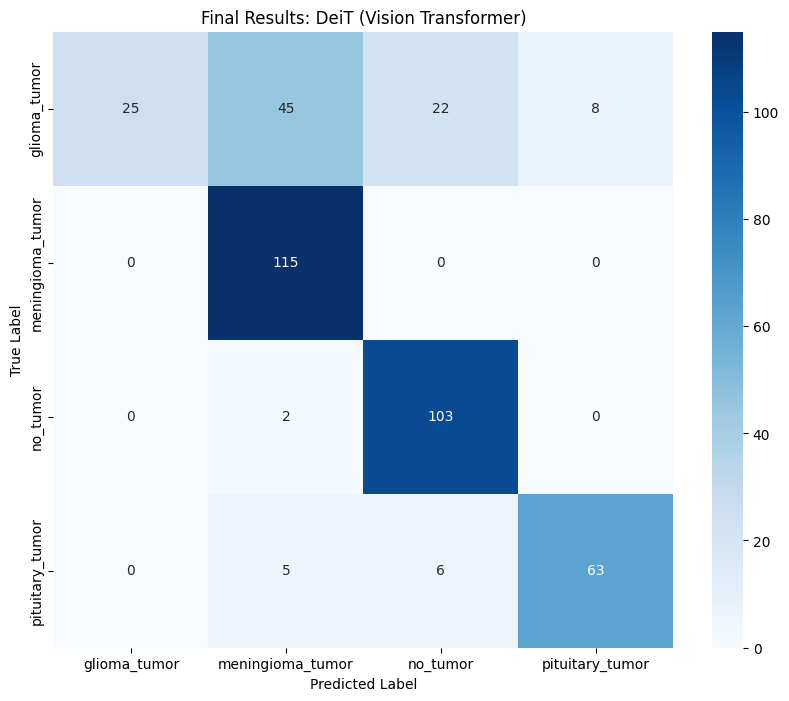

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

print("Running final Test Set inference...")
with torch.no_grad():
    for images, labels in test_ds:

        images_torch = torch.from_numpy(images.numpy()).permute(0, 3, 1, 2).to(device).float() / 255.0
        labels_np = labels.numpy().argmax(axis=1)


        outputs = model_deit(images_torch)
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_np)


class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
print("\n--- FINAL DEIT TEST REPORT ---")
print(classification_report(all_labels, all_preds, target_names=class_names))


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Results: DeiT (Vision Transformer)')
plt.show()

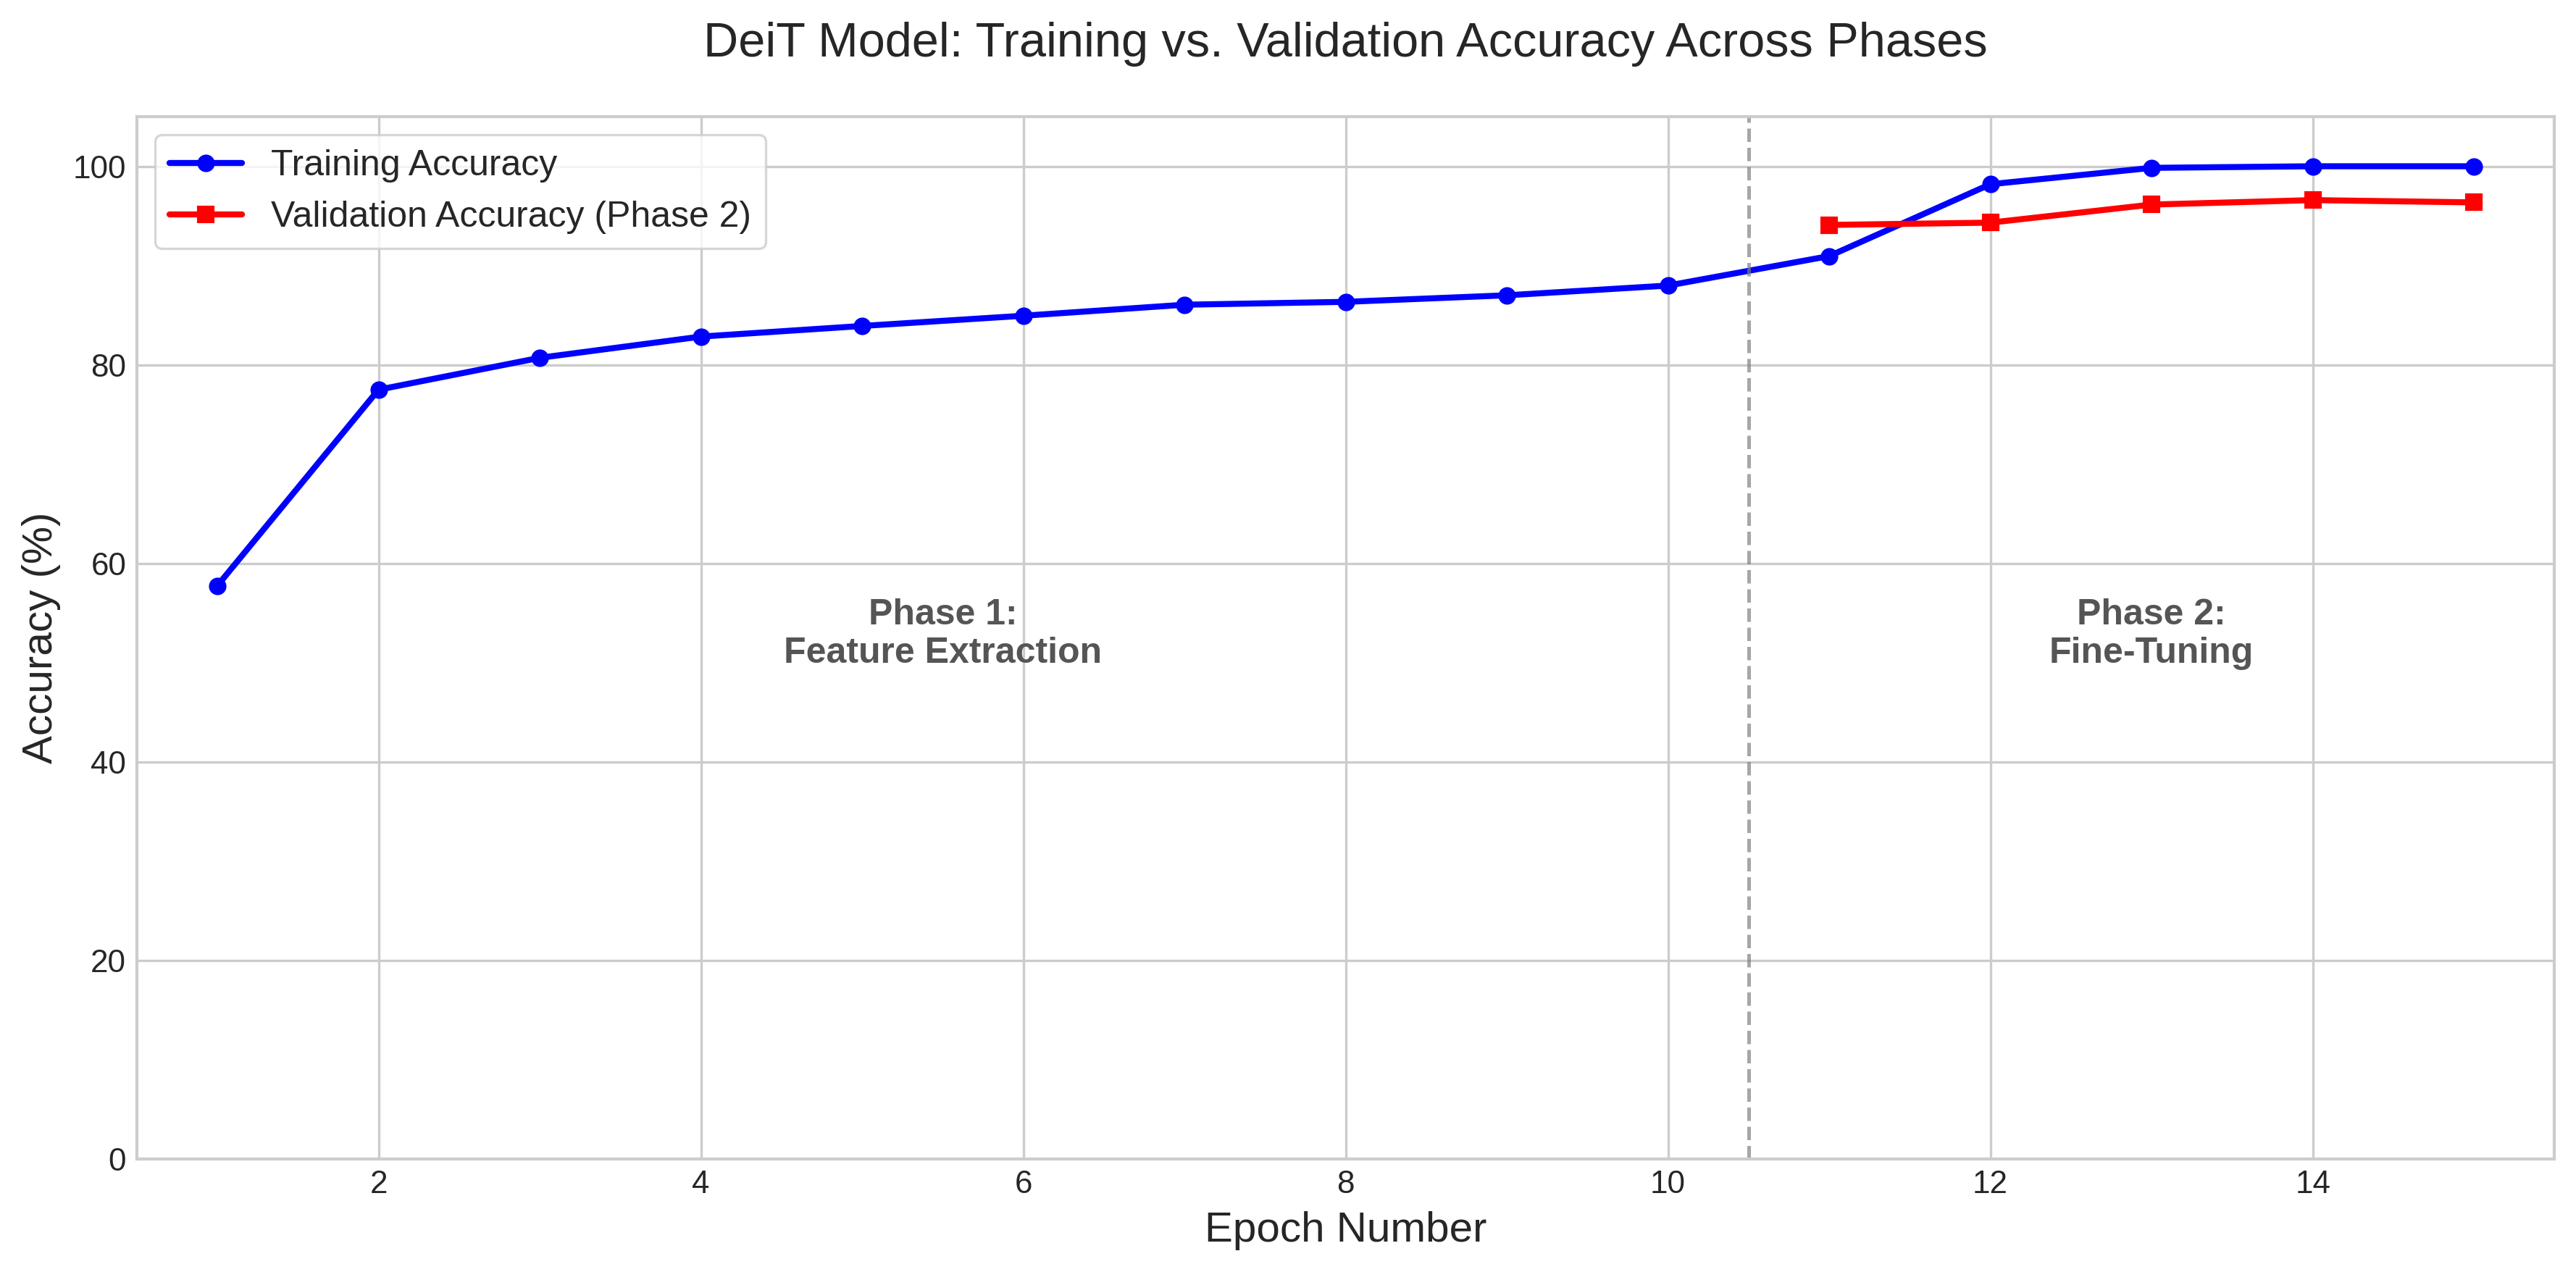

✓ Saved cleaned version to: /content/drive/My Drive/Kaggle_Datasets/mri-brain-tumor-dataset/deit_learning_curve_REVISED.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os


epochs = np.arange(1, 16)


train_acc = [57.74, 77.49, 80.70, 82.84, 83.91, 84.94, 86.05, 86.34, 87.00, 87.98, 90.95, 98.19, 99.84, 100.00, 100.00]


val_acc = [np.nan]*10 + [94.09, 94.32, 96.14, 96.59, 96.36]


plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-whitegrid')


plt.plot(epochs, train_acc, color='blue', marker='o', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, color='red', marker='s', label='Validation Accuracy (Phase 2)', linewidth=2)


plt.axvline(x=10.5, color='gray', linestyle='--', alpha=0.7)
plt.text(5.5, 50, 'Phase 1:\nFeature Extraction', fontsize=12, ha='center', fontweight='bold', color='#555555')
plt.text(13, 50, 'Phase 2:\nFine-Tuning', fontsize=12, ha='center', fontweight='bold', color='#555555')


plt.title('DeiT Model: Training vs. Validation Accuracy Across Phases', fontsize=16, pad=20)
plt.xlabel('Epoch Number', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)


plt.ylim(0, 105)
plt.xlim(0.5, 15.5)

plt.legend(frameon=True, facecolor='white', fontsize=12)
plt.tight_layout()


save_path = os.path.join(base_path, 'deit_learning_curve_REVISED.png')
plt.savefig(save_path, dpi=300)
plt.show()

print(f"✓ Saved cleaned version to: {save_path}")

In [6]:

!pip install torchinfo

from torchinfo import summary

model_stats = summary(model_deit, input_size=(1, 3, 224, 224),
                      col_names=["input_size", "output_size", "num_params", "kernel_size"],
                      depth=3)
print(model_stats)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
VisionTransformerDistilled               [1, 3, 224, 224]          [1, 4]                    153,600                   --
├─PatchEmbed: 1-1                        [1, 3, 224, 224]          [1, 196, 768]             --                        --
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 768, 14, 14]          (590,592)                 [16, 16]
│    └─Identity: 2-2                     [1, 196, 768]             [1, 196, 768]             --                        --
├─Dropout: 1-2                           [1, 198, 768]             [1, 198, 768]             --                        --
├─Identity: 1-3                          [1, 198, 768]             [1, 198, 768]             --                        --
├─Identity: 1-4                          [1, 198, 768]             [1, 198, 768]             --                        --
├─Sequen